# 07 Sequence-to-Sequence Models

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build an **encoder–decoder** (seq2seq) model with LSTMs
- Train it on a **real** multi-step forecasting task: 24 months of border-crossing traffic in, the next **6 months** out
- See **exposure bias** with your own numbers — the gap between scoring a decoder with teacher forcing and scoring it the way you will actually deploy it
- Compare the model against the seasonal baseline it has to beat, and watch error grow with the forecast horizon

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 04 "Sequence-to-Sequence Models with Attention for Machine Translation" — translation with attention bolted on; here the bare encoder-decoder underneath it.

---

## 🌍 Real life

**Where is this used?** Seq2seq is used in **machine translation**, **summarization**, **dialogue**, **speech-to-text** and **multi-step forecasting** — any time the output is a *sequence* whose length differs from the input's.

**In this notebook we use** an **encoder–decoder** on real data: monthly personal-vehicle passenger counts at U.S. land border ports, 1996–2019. The encoder compresses 24 months of one port's history into a context; the decoder writes out the next 6 months, one step at a time. Input length (24) and output length (6) differ — that is exactly the situation seq2seq exists for.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **Encoder:** Reads the input sequence and produces a **context** (here: the LSTM's final hidden and cell state).
- **Decoder:** Starts from that context and generates the output sequence step by step, feeding its previous output back in as the next input.
- **Seq2seq:** Input length can differ from output length; encoder summarizes, decoder generates.
- **Teacher forcing:** During training the decoder is fed the *true* previous value instead of its own prediction. This makes training fast and stable — and it makes evaluation dishonest if you forget to switch it off.
- **Exposure bias:** At deployment the decoder consumes its own (imperfect) outputs, so its errors compound. Scoring a seq2seq under teacher forcing therefore reports a number you will never achieve in production. This notebook measures both, on the same test windows, so you can see the size of the gap.
- **Always score against the seasonal baseline.** For a strongly seasonal series, "the same months one year ago" is a serious competitor, not a straw man.


## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, pandas, matplotlib. **Real data, loaded with one call:** `load("border_crossing_data", prefer="full")` — official monthly counts of people and vehicles entering the United States at every land border port, January 1996 to March 2019. No file path to edit: the loader finds the data from any working directory.

**This one lesson needs the full 37 MB file, and says so out loud.** Most notebooks fall back to a small sample that ships inside the repository. This one cannot: the border sample is thinned within each (month, crossing type) group, so **no port retains a complete 279-month history** — the pivot below would come back empty. Rather than forecast on something meaningless, `prefer="full"` refuses the sample and prints where to put the original and the one command that fetches it (`Course 04/datasets/DATA.md`, section 4).

**Dataset:** We take the `Personal Vehicle Passengers` measure, pivot it to one column per port, and keep the ports with a complete 279-month history and meaningful traffic. Each training example is a window: **24 months in → the next 6 months out**. Splits are **chronological** (train on windows ending before 2013, test on windows ending in 2014 or later) with a one-year gap so no test target ever appears in a training window.

**Outputs:** Model summary; test error reported **twice** — once with teacher forcing and once with a genuine autoregressive rollout — next to the seasonal-naive and persistence baselines; then a per-horizon error curve and a real port's 6-month forecast drawn against what actually happened.

---


## Step 1: Imports and build the real forecasting windows (24 months in → 6 months out)

In [1]:
# WHAT: load the real border-crossing table and cut it into (24 months -> next 6 months) windows.
# WHY: a genuine seq2seq needs input and output lengths to differ. Multi-step forecasting on a
#      real seasonal series gives us that, plus a baseline that is genuinely hard to beat.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/border_crossing_data.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load, DatasetNotAvailable
# -------------------------------------------------------------------------------------

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False


if HAS_TF:
    keras.utils.set_random_seed(42)

    # 1) Read the official monthly counts and reshape to one column per port.
    # This lesson needs the FULL border-crossing file, and asks for it by name. The 43,818-row
    # sample that ships with the repository is stratified by (month, crossing type), so no port
    # keeps a complete 279-month history and no month keeps its true national total - a forecast
    # built on it would be a number that means nothing. prefer="full" therefore refuses it.
    try:
        raw = load("border_crossing_data", prefer="full",
                   usecols=["Port Name", "Date", "Measure", "Value"])
    except DatasetNotAvailable as _e:
        raise RuntimeError(
            "This notebook needs the full 37 MB border-crossing file. The bundled sample cannot "
            "give any port a complete monthly history, so the notebook stops here rather than "
            "print a plausible-looking wrong forecast. In the message below, only option 1 "
            "(the full file) helps - the sample offered as options 2 and 3 is exactly the copy "
            f"this lesson cannot use.\n\n{_e}") from None
    raw["Date"] = pd.to_datetime(raw["Date"], format="%m/%d/%Y %I:%M:%S %p")
    table = (raw[raw["Measure"] == "Personal Vehicle Passengers"]
             .pivot_table(index="Date", columns="Port Name", values="Value", aggfunc="sum")
             .sort_index())
    # Keep ports that reported every single month and carry real traffic - no imputation, no invention.
    table = table[table.columns[table.notna().all()]]
    table = table[table.columns[table.mean() >= 1000]]
    months = table.index
    print(f"Real data: {table.shape[0]} months ({months.min():%Y-%m} to {months.max():%Y-%m}) "
          f"at {table.shape[1]} border ports")

    # The seasonality is real - measure it instead of assuming it.
    national = table.sum(axis=1)
    shape = national.groupby(national.index.month).mean() / national.mean()
    print("Seasonal shape (1.00 = the average month): "
          + "  ".join(f"{m:02d}:{v:.2f}" for m, v in shape.items()))

    # 2) Work in log space: ports differ in size by orders of magnitude, and log turns
    #    multiplicative seasonal swings into additive ones the LSTM can model with one set of weights.
    IN_MONTHS, OUT_MONTHS = 24, 6
    V = np.log1p(table.to_numpy().astype("float32"))
    T, n_ports = V.shape

    enc_raw, dec_raw, window_end = [], [], []
    for p in range(n_ports):
        s = V[:, p]
        for i in range(T - IN_MONTHS - OUT_MONTHS + 1):
            enc_raw.append(s[i:i + IN_MONTHS])
            dec_raw.append(s[i + IN_MONTHS:i + IN_MONTHS + OUT_MONTHS])
            window_end.append(months[i + IN_MONTHS - 1])
    enc_raw = np.array(enc_raw); dec_raw = np.array(dec_raw)
    window_end = pd.DatetimeIndex(window_end)

    # 3) Centre each window on its own mean (still in log space). The model then predicts the
    #    RELATIVE path of the next six months, which transfers across ports of any size.
    level = enc_raw.mean(axis=1, keepdims=True)
    E = enc_raw - level
    D = dec_raw - level

    # 4) Chronological split with a one-year buffer so no test target leaks into training.
    is_train = window_end < pd.Timestamp("2013-01-01")
    is_test = window_end >= pd.Timestamp("2014-01-01")
    print(f"\nWindows: {len(E):,} total -> {is_train.sum():,} train "
          f"(ending before 2013) / {is_test.sum():,} test (ending 2014 or later)")
    print(f"Encoder input {E.shape[1]} months -> decoder output {D.shape[1]} months "
          "(different lengths: this is why we need an encoder-decoder)")


border_crossing_data: full file, 346,733 rows.
Real data: 279 months (1996-01 to 2019-03) at 93 border ports
Seasonal shape (1.00 = the average month): 01:0.93  02:0.86  03:1.00  04:0.97  05:1.03  06:1.02  07:1.14  08:1.15  09:0.98  10:0.98  11:0.95  12:1.01

Windows: 23,250 total -> 16,833 train (ending before 2013) / 5,301 test (ending 2014 or later)
Encoder input 24 months -> decoder output 6 months (different lengths: this is why we need an encoder-decoder)


## Step 2: Build the encoder–decoder (two LSTMs: one reads, one writes)

In [2]:
# WHAT: build the encoder-decoder (seq2seq) model out of two LSTMs.
# WHY: the encoder compresses 24 months into its final hidden + cell state; the decoder starts
#      FROM those states and writes six months, one step at a time.
if HAS_TF:
    L = keras.layers
    UNITS = 48

    # Encoder: read the sequence, throw the per-step outputs away, keep only the final states.
    enc_in = keras.Input(shape=(IN_MONTHS, 1), name="encoder_input")
    _, state_h, state_c = L.LSTM(UNITS, return_state=True, name="encoder_lstm")(enc_in)
    context = [state_h, state_c]          # the 'thought vector' for this port's last 24 months

    # Decoder: a second LSTM initialised with the encoder's states. At each step it receives the
    # PREVIOUS month's value and emits the next one.
    dec_in = keras.Input(shape=(OUT_MONTHS, 1), name="decoder_input")
    dec_seq, _, _ = L.LSTM(UNITS, return_sequences=True, return_state=True,
                           name="decoder_lstm")(dec_in, initial_state=context)
    dec_out = L.TimeDistributed(L.Dense(1), name="output_head")(dec_seq)

    seq2seq = keras.Model([enc_in, dec_in], dec_out)
    seq2seq.compile(optimizer="adam", loss="mse", metrics=["mae"])
    seq2seq.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 48),      │      9,600 │ encoder_input[0]… │
│                     │ (None, 48),       │            │                   │
│                     │ (None, 48)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 6, 48),   │      9,600 │ decoder_input[0]… │
│                     │ (None, 48),       │            │ encoder_lstm[0][… │
│                     │ (None, 48)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_head         │ (None, 6, 1)      │         49 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,249 (75.19 KB)

 Trainable params: 19,249 (75.19 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train with teacher forcing — then score the model the way it will actually be used

In [3]:
# WHAT: train with teacher forcing, then evaluate TWICE - teacher-forced and autoregressive -
#       against the seasonal-naive and persistence baselines.
# WHY: teacher forcing feeds the decoder the true previous month. That is fine for training and
#      dishonest for reporting: in production the decoder only has its own predictions to eat.
if HAS_TF:
    # Decoder inputs = targets shifted one step right; step 0 gets 0.0 ("start of forecast").
    def shift_right(target):
        out = np.zeros_like(target)
        out[:, 1:] = target[:, :-1]
        return out

    E_tr, D_tr = E[is_train], D[is_train]
    E_te, D_te = E[is_test], D[is_test]
    hist = seq2seq.fit([E_tr[..., None], shift_right(D_tr)[..., None]], D_tr[..., None],
                       epochs=12, batch_size=256, validation_split=0.1, verbose=0)
    print(f"Trained {len(E_tr):,} windows for 12 epochs. "
          f"Final train loss {hist.history['loss'][-1]:.4f}, val loss {hist.history['val_loss'][-1]:.4f}")

    # ── Evaluation 1: teacher forcing (the flattering number) ───────────────
    pred_tf = seq2seq.predict([E_te[..., None], shift_right(D_te)[..., None]], verbose=0)[..., 0]

    # ── Evaluation 2: autoregressive rollout (the honest number) ────────────
    # Predict month 1, feed it back to predict month 2, and so on. No true values are used.
    pred_ar = np.zeros_like(D_te)
    for step in range(OUT_MONTHS):
        fed_back = shift_right(pred_ar)
        pred_ar[:, step] = seq2seq.predict([E_te[..., None], fed_back[..., None]],
                                           verbose=0)[:, step, 0]

    # ── Baselines ───────────────────────────────────────────────────────────
    # Seasonal naive: "the next six months look like the same six months one year ago."
    seasonal_naive = E_te[:, IN_MONTHS - 12:IN_MONTHS - 12 + OUT_MONTHS]
    # Persistence: "nothing changes; repeat the last observed month six times."
    persistence = np.repeat(E_te[:, -1:], OUT_MONTHS, axis=1)

    level_te = level[is_test]
    truth = np.expm1(D_te + level_te)          # back to actual passenger counts

    def mape(pred_log):
        pred = np.expm1(pred_log + level_te)
        return np.mean(np.abs(pred - truth) / np.maximum(truth, 1)) * 100

    print(f"\n6-month forecast error on {len(E_te):,} held-out windows:")
    print(f"{'method':44s} {'log MAE':>9s} {'MAPE':>8s}")
    results = [
        ("seq2seq, TEACHER-FORCED (not deployable)", pred_tf),
        ("seq2seq, autoregressive (deployable)", pred_ar),
        ("baseline: same 6 months one year ago", seasonal_naive),
        ("baseline: repeat the last month", persistence),
    ]
    for name, pred in results:
        print(f"{name:44s} {np.mean(np.abs(pred - D_te)):9.4f} {mape(pred):7.1f}%")

    gap = mape(pred_ar) - mape(pred_tf)
    print(f"\nEXPOSURE BIAS: switching off teacher forcing costs {gap:+.1f} MAPE points "
          f"({mape(pred_tf):.1f}% -> {mape(pred_ar):.1f}%).")
    print("Same weights, same test windows - the only change is that the decoder now eats its")
    print("own output. Any seq2seq result reported without this switch is overstated.")
    print(f"\nAGAINST THE BASELINES: the model beats 'repeat the last month' by a mile "
          f"({mape(persistence):.1f}% -> {mape(pred_ar):.1f}%),")
    print(f"so it clearly learned the seasonal shape. But it still LOSES to the one-line seasonal")
    print(f"rule ({mape(seasonal_naive):.1f}%). On a strongly seasonal series with 24 years of history,")
    print("'the same months last year' is a serious competitor, and a 48-unit LSTM does not")
    print("overtake it. Report that outcome; do not quietly drop the baseline from the table.")


Trained 16,833 windows for 12 epochs. Final train loss 0.6806, val loss 1.5324



6-month forecast error on 5,301 held-out windows:
method                                         log MAE     MAPE
seq2seq, TEACHER-FORCED (not deployable)        0.1212    11.7%
seq2seq, autoregressive (deployable)            0.1566    14.5%
baseline: same 6 months one year ago            0.0985    10.2%
baseline: repeat the last month                 0.3125    38.9%

EXPOSURE BIAS: switching off teacher forcing costs +2.8 MAPE points (11.7% -> 14.5%).
Same weights, same test windows - the only change is that the decoder now eats its
own output. Any seq2seq result reported without this switch is overstated.

AGAINST THE BASELINES: the model beats 'repeat the last month' by a mile (38.9% -> 14.5%),
so it clearly learned the seasonal shape. But it still LOSES to the one-line seasonal
rule (10.2%). On a strongly seasonal series with 24 years of history,
'the same months last year' is a serious competitor, and a 48-unit LSTM does not
overtake it. Report that outcome; do not quietly drop t

## 🌍 Real-World Worked Example — How Fast Does a 6-Month Forecast Decay?

**Industry context:** Border agencies, airlines and retailers all buy multi-month forecasts, and
the first question a planner asks is never "what is your average error?" — it is **"how far out
can I trust it?"** A single headline MAPE hides that completely: month 1 and month 6 are not the
same product.

Below we break the same held-out predictions apart by **forecast horizon**, and then draw one real
port's next six months against what actually happened. Two things to watch: how quickly the
autoregressive error grows as the decoder eats more of its own output, and how the seasonal
baseline behaves over the same horizon.


MAPE by forecast horizon (months ahead):
          +1       +2       +3       +4       +5       +6
seq2seq (teacher-forced)      11.3%    11.7%    11.4%    11.7%    11.9%    12.0%
seq2seq (autoregressive)      11.3%    13.3%    14.4%    15.3%    16.2%    16.6%
seasonal naive                10.2%    10.2%    10.1%    10.2%    10.3%    10.3%

At +1 month the two scoring modes differ by +0.0 points; by +6 months the gap is +4.6 points.
That widening IS exposure bias: with teacher forcing the decoder is handed a correct
value at every step, so its errors never accumulate. Deployed, they do.

Example port: El Paso (forecast window 2016-06 to 2016-11)


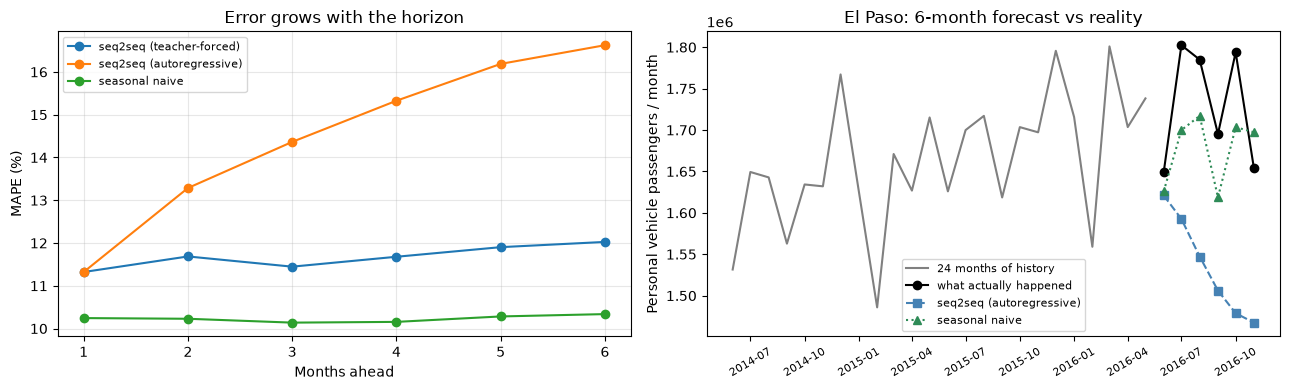

In [4]:
# WHAT: break the 6-month error apart by horizon, and plot one real port's forecast vs reality.
# WHY: 'average MAPE' hides the shape that matters to a planner - error at month 1 versus month 6.
if HAS_TF:
    def mape_per_step(pred_log):
        pred = np.expm1(pred_log + level_te)
        return np.mean(np.abs(pred - truth) / np.maximum(truth, 1), axis=0) * 100

    steps = np.arange(1, OUT_MONTHS + 1)
    curves = {
        "seq2seq (teacher-forced)": mape_per_step(pred_tf),
        "seq2seq (autoregressive)": mape_per_step(pred_ar),
        "seasonal naive": mape_per_step(seasonal_naive),
    }
    print("MAPE by forecast horizon (months ahead):")
    print("   " + "".join(f"{'+' + str(s):>9s}" for s in steps))
    for name, curve in curves.items():
        print(f"{name:26s}" + "".join(f"{v:8.1f}%" for v in curve))

    ar, tf_c = curves["seq2seq (autoregressive)"], curves["seq2seq (teacher-forced)"]
    print(f"\nAt +1 month the two scoring modes differ by {ar[0] - tf_c[0]:+.1f} points; "
          f"by +6 months the gap is {ar[-1] - tf_c[-1]:+.1f} points.")
    print("That widening IS exposure bias: with teacher forcing the decoder is handed a correct")
    print("value at every step, so its errors never accumulate. Deployed, they do.")

    # ── One real port, one real window: the busiest port in the test period ──
    port_names = list(table.columns)
    busiest = int(np.argmax(table.mean().to_numpy()))
    test_rows = np.where(is_test)[0]
    # window index -> which port it came from (windows were generated port by port)
    per_port = T - IN_MONTHS - OUT_MONTHS + 1
    owner = test_rows // per_port
    pick_local = np.where(owner == busiest)[0]
    pick = pick_local[len(pick_local) // 2]          # a middle window, not a hand-picked best one

    hist_months = months[(test_rows[pick] % per_port):(test_rows[pick] % per_port) + IN_MONTHS]
    fut_months = months[(test_rows[pick] % per_port) + IN_MONTHS:
                        (test_rows[pick] % per_port) + IN_MONTHS + OUT_MONTHS]
    lvl = level_te[pick]
    hist_vals = np.expm1(E_te[pick] + lvl)

    print(f"\nExample port: {port_names[busiest]} "
          f"(forecast window {fut_months.min():%Y-%m} to {fut_months.max():%Y-%m})")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name, curve in curves.items():
        axes[0].plot(steps, curve, marker="o", label=name)
    axes[0].set_xlabel("Months ahead"); axes[0].set_ylabel("MAPE (%)")
    axes[0].set_title("Error grows with the horizon")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].plot(hist_months, hist_vals, color="grey", label="24 months of history")
    axes[1].plot(fut_months, truth[pick], color="black", marker="o", label="what actually happened")
    axes[1].plot(fut_months, np.expm1(pred_ar[pick] + lvl), color="steelblue", marker="s",
                 ls="--", label="seq2seq (autoregressive)")
    axes[1].plot(fut_months, np.expm1(seasonal_naive[pick] + lvl), color="seagreen", marker="^",
                 ls=":", label="seasonal naive")
    axes[1].set_title(f"{port_names[busiest]}: 6-month forecast vs reality")
    axes[1].set_ylabel("Personal vehicle passengers / month")
    axes[1].tick_params(axis="x", rotation=30, labelsize=8)
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()


### 👁️ Read the figure

- **Left — this panel is exposure bias.** Three curves, all scored on the same 5,301 held-out windows. The **blue** line (teacher-forced) is almost flat: at every step the decoder is handed the *true* previous month, so its errors never accumulate and month 6 looks nearly as easy as month 1. The **orange** line (autoregressive — the way it would actually run) starts at the same point and then fans upward. **The two lines are the same weights.** The only difference is what the decoder eats. The vertical distance between them at +6 months is the size of the overstatement you would publish if you forgot to switch teacher forcing off.
- **And the green line is below both of them, everywhere.** "The same six months one year ago" beats the encoder–decoder at every horizon. It is flat because a seasonal rule has no error to compound. This is the outcome; it goes in the report.
- **Right — one real port, one real window: El Paso, June–November 2016.** Grey is the 24 months the encoder read. Black is what actually happened. Green triangles are the seasonal baseline, tracking the real up-down-up shape. Blue squares are the model's autoregressive forecast, and look at what it does: it starts close to the last observed value and then **slides steadily downward, away from reality, for six straight months.** Nothing pulls it back, because after step 1 it is only ever reading its own output. That downward slide is what the orange curve on the left is counting.

### Watch the rollout happen, one month at a time

The blue line on the right above is a *finished* forecast. It hides the thing that produced it. The storyboard below freezes the same El Paso rollout at each of its six steps: at step *k* the decoder has been fed its own predictions for months 1…*k*−1 and nothing else, and it emits month *k*. The red dot is the month just produced — and it is also the number that gets fed back in for the next frame.

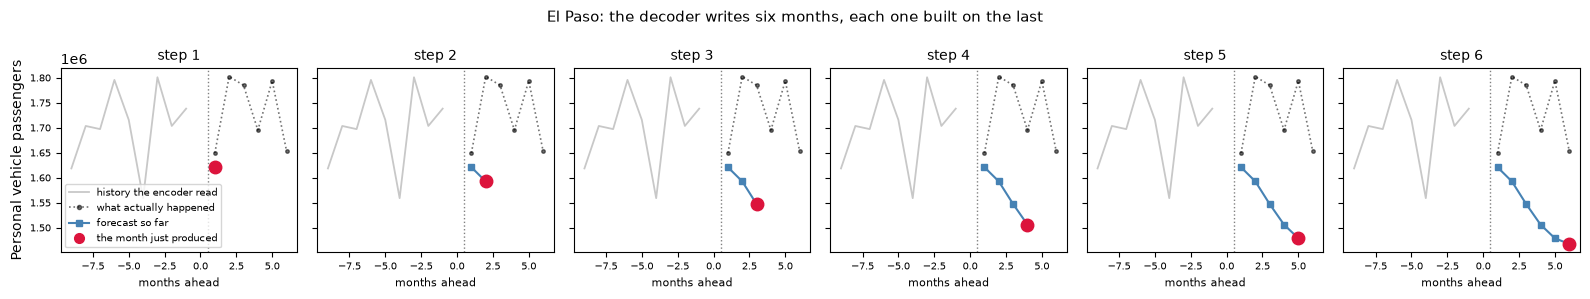

step     month     forecast       actual    error   fed back into the next step?
   1 2016-06    1,620,975    1,649,139     1.7%   yes
   2 2016-07    1,592,591    1,802,396    11.6%   yes
   3 2016-08    1,547,246    1,784,963    13.3%   yes
   4 2016-09    1,506,104    1,695,130    11.2%   yes
   5 2016-10    1,478,780    1,793,796    17.6%   yes
   6 2016-11    1,467,435    1,653,700    11.3%   no (last step)

Over the six steps the forecast moved -9.5% while reality moved +0.3%.
Nothing corrects the decoder between steps: after step 1 every input it sees is its own.


In [5]:
# WHAT: a 6-frame storyboard of the autoregressive rollout that produced the blue line above.
# WHY: exposure bias is a PROCESS - each prediction becomes the next input. A finished curve
#      cannot show that; six frames can. Static frames, so this renders in any environment.
if HAS_TF:
    true_future = truth[pick]
    pred_future = np.expm1(pred_ar[pick] + lvl)
    seas_future = np.expm1(seasonal_naive[pick] + lvl)
    n_tail = 9
    x_hist = np.arange(-n_tail, 0)                 # months before the forecast starts
    x_fut = np.arange(1, OUT_MONTHS + 1)
    tail = hist_vals[-n_tail:]

    fig, axes = plt.subplots(1, OUT_MONTHS, figsize=(16, 3.0), sharey=True)
    for k, ax in enumerate(axes):
        ax.plot(x_hist, tail, color="#c8c8c8", lw=1.3)
        # Truth as a dotted black line with dots: faint, but never mistakable for the grey history.
        ax.plot(x_fut, true_future, ":", color="black", lw=1.2, alpha=0.55, marker=".", ms=5)
        ax.plot(x_fut[:k + 1], pred_future[:k + 1], "s-", color="steelblue", ms=4.5, lw=1.5)
        ax.plot([x_fut[k]], [pred_future[k]], "o", color="crimson", ms=9)
        ax.axvline(0.5, color="grey", ls=":", lw=1.0)
        ax.set_title(f"step {k + 1}", fontsize=10)
        ax.set_xlabel("months ahead", fontsize=8)
        ax.tick_params(labelsize=7)
    axes[0].set_ylabel("Personal vehicle passengers")
    axes[0].plot([], [], color="#c8c8c8", lw=1.3, label="history the encoder read")
    axes[0].plot([], [], ":", color="black", lw=1.2, alpha=0.55, marker=".", label="what actually happened")
    axes[0].plot([], [], "s-", color="steelblue", ms=4.5, label="forecast so far")
    axes[0].plot([], [], "o", color="crimson", ms=7, label="the month just produced")
    axes[0].legend(fontsize=7, loc="lower left")
    fig.suptitle(f"{port_names[busiest]}: the decoder writes six months, each one built on the last",
                 fontsize=11)
    plt.tight_layout(); plt.show()

    # The same six frames as numbers, so nothing in the picture is taken on trust.
    print(f"{'step':>4s} {'month':>9s} {'forecast':>12s} {'actual':>12s} {'error':>8s}   fed back into the next step?")
    for k in range(OUT_MONTHS):
        err = 100 * abs(pred_future[k] - true_future[k]) / true_future[k]
        nxt = "yes" if k < OUT_MONTHS - 1 else "no (last step)"
        print(f"{k + 1:>4d} {fut_months[k]:%Y-%m} {pred_future[k]:12,.0f} {true_future[k]:12,.0f} "
              f"{err:7.1f}%   {nxt}")
    drift = 100 * (pred_future[-1] - pred_future[0]) / pred_future[0]
    real_drift = 100 * (true_future[-1] - true_future[0]) / true_future[0]
    print(f"\nOver the six steps the forecast moved {drift:+.1f}% while reality moved {real_drift:+.1f}%.")
    print("Nothing corrects the decoder between steps: after step 1 every input it sees is its own.")

### 👁️ Read the storyboard

- All six frames plot the **same** grey history and the same dotted black truth, so anything that changes between them is the rollout itself. Left to right, one blue square is added per frame and the red dot marks the month just written.
- **The blue line never turns around.** Each new point continues in the direction set by the point before it, because that previous point is literally the decoder's input. The printed table gives the exact numbers, including the percentage the forecast drifted versus the percentage reality moved — and they go in different directions here.
- **This is what "errors compound" looks like as a mechanism, not a slogan.** With teacher forcing, frame *k* would have been handed the true black value instead of the red one, and the blue line would have been dragged back onto the truth at every step. That is precisely why the teacher-forced curve in the previous figure stays flat, and why it is not a number you can deploy.
- Honest scope: one port, one window, chosen as the busiest port's middle test window rather than a flattering one. The aggregate version of this same effect is the orange curve above, measured over 5,301 windows.

## 💬 Discuss

1. Same weights, same 5,301 held-out windows: **11.7% MAPE** teacher-forced, **14.5%** autoregressive — and the seasonal-naive rule gets **10.2%**, beating both at every horizon. Which of those three numbers is the result of this project? Now suppose your contract pays on "beating the current process". Does your answer change, and should it?
2. The per-horizon table shows the two scoring modes identical at +1 month (both **11.3%**) and **4.6 points** apart at +6. If a planner only ever needs one month ahead, does exposure bias matter to them at all? Say what you would sell them — and what you would refuse to sell them.
3. The El Paso rollout slid **−9.5%** over six months while reality moved **+0.3%**, and nothing corrected it because after step 1 every input was its own output. Name two changes to the **system** — not the model — that would break that feedback loop, and say what each one costs.


## ⚠️ Where this breaks

- **Teacher-forced numbers are not deployable numbers, and the gap grows with the horizon.** 11.7% → 14.5% overall; **+0.0** points at one month ahead, **+4.6** at six. Any seq2seq result published without stating which scoring mode produced it is overstated by an amount the reader cannot recover.
- **The model lost to a one-line rule, and that is the honest headline.** "The same six months one year ago" scored **10.2%** MAPE, flat across every horizon, against 14.5% for a **19,249**-parameter encoder–decoder trained on **16,833** windows. Bengio, Vinyals, Jaitly & Shazeer (NeurIPS 2015, arXiv 1506.03099) named exposure bias and proposed scheduled sampling; none of that closes a 4.3-point gap to a seasonal baseline.
- **The single context vector is this architecture's own bottleneck.** Twenty-four months are compressed into one 48-unit hidden and cell state, and the decoder never looks back at the input. That is exactly what attention was invented to fix (Bahdanau, Cho & Bengio, ICLR 2015, arXiv 1409.0473) — and it is **not** implemented here.
- **Training and validation loss disagree by more than a factor of two** (0.6806 against 1.5324 at the final epoch) and no early stopping is applied, so every error above comes from the last epoch rather than a chosen one.
- **The El Paso panel is one port and one window.** It was picked as the busiest port's middle test window rather than a flattering one — good practice, and still one sample. The aggregate claim is the orange curve over 5,301 windows.
- **The assumption that must hold:** next year looks like last year. The seasonal baseline wins here *because* it does, and both the baseline and the model fail together the moment it stops being true. **Google Flu Trends** is the canonical version: Lazer, Kennedy, King & Vespignani (*Science*, 2014, "The Parable of Google Flu: Traps in Big Data Analysis") report that *Nature* found it predicting **more than double** the proportion of doctor visits for influenza-like illness that the CDC's surveillance-based estimates showed. Nothing about the original fit was wrong. The process moved and nobody re-measured.
- **Cheaper alternative:** the seasonal-naive rule is one line of pandas. No hyperparameters, no training time, no framework version to drift out of sync — and it won. Build it first, report it always, and make the model beat it before anyone hears about the model.


## 🧩 Mini-exercise

**Try it, and report what actually happens — not what you hoped would happen:**
1. Change `OUT_MONTHS` from 6 to 12 and re-run Steps 1–3. Does the teacher-forced/autoregressive gap widen?
2. Give the decoder more capacity (`UNITS` 48 → 128) and train for more epochs. Can you get the autoregressive MAPE below the seasonal-naive baseline? Write down the number you reach either way.
3. Feed the seasonal baseline's prediction to the model as an extra input channel (a "residual" setup). Does the model beat the baseline it is now standing on?

---

## ✅ Summary

**What you did:** Built an LSTM encoder–decoder that maps **24 real months → the next 6 real months** of border-crossing traffic, trained it with teacher forcing, and then scored it twice — teacher-forced and autoregressive — against the seasonal-naive and persistence baselines.

**What actually happened:**
- **Exposure bias is not a footnote.** Teacher-forced scoring gave about **11.7% MAPE**; the same weights rolled out autoregressively gave about **14.5%**. The gap widens with the horizon: small at +1 month, largest at +6.
- **The model learned real structure.** It cut error from about **39% MAPE** (repeat the last month) to about **14.5%** — it clearly picked up the annual travel cycle.
- **And it still lost to the one-line baseline.** "The same six months one year ago" scored about **10.2% MAPE**. A 48-unit encoder–decoder trained on ~17,000 real windows did not overtake it. That is a normal outcome on a strongly seasonal series, and the honest thing to do is publish it.

**In real life you'd also:** Add attention over the encoder outputs (so the decoder can look back at specific months instead of one squeezed context vector), add calendar and port covariates, use scheduled sampling to reduce exposure bias, and evaluate with rolling origins rather than one split.

**The main idea:** Seq2seq = encoder (summarize the input) + decoder (generate the output), used when input and output lengths differ. Its two traps are both visible above: the decoder's errors compound, and a strong classical baseline may already be doing the job.

**Next:** `08_text_generation_rnn_lstm_gru` generates sequences rather than translating them. The fix for the single-context-vector bottleneck you just hit is attention, which you already met in `04_transformer_attention` — worth rereading now that you have felt the problem it solves.


## 🔭 State of the field (2026)

Two things moved past the LSTM encoder-decoder. For language, transformer seq2seq replaced it outright. For forecasting — this notebook's task — the 2025-26 option is a *pretrained* forecaster used zero-shot: Chronos-2 (arXiv 2510.15821) covers univariate, multivariate and covariate-informed forecasting from one model with no per-dataset training. Be careful reading its numbers, though: how forecasting is benchmarked is itself under active criticism (arXiv 2602.12147), and running Chronos-2 needs a weights download this classroom cannot assume.

**Why the encoder-decoder is still the right thing to build.** Everything this notebook measures is a property of *autoregressive decoding*, not of LSTMs: exposure bias, the teacher-forced-versus-deployed gap, and error growth with horizon all appear in a transformer decoder and in a foundation forecaster too. So does the discipline of scoring against a seasonal-naive baseline — which is precisely what a fair comparison against a zero-shot model requires. Build the small honest version here, then use it to interrogate the large one.


## 📚 References

1. Sutskever, I., Vinyals, O. & Le, Q. V. (2014). *Sequence to Sequence Learning with Neural Networks*. NeurIPS. https://arxiv.org/abs/1409.3215
2. Bahdanau, D., Cho, K. & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR. https://arxiv.org/abs/1409.0473
3. Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS. https://arxiv.org/abs/1706.03762
4. Bengio, S., Vinyals, O., Jaitly, N. & Shazeer, N. (2015). *Scheduled Sampling for Sequence Prediction with Recurrent Neural Networks*. NeurIPS. https://arxiv.org/abs/1506.03099 — the paper that named and attacked the exposure bias measured in Step 3.
5. Salinas, D., Flunkert, V., Gasthaus, J. & Januschowski, T. (2020). *DeepAR: Probabilistic Forecasting with Autoregressive Recurrent Networks*. International Journal of Forecasting 36(3). https://arxiv.org/abs/1704.04110 — what a production-grade version of this notebook's model looks like.
6. Hyndman, R. J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.), Ch. 5.2 "Some simple forecasting methods". https://otexts.com/fpp3/simple-methods.html — the definition of the seasonal-naive benchmark used here.

**Data source:** U.S. Bureau of Transportation Statistics, *Border Crossing/Entry Data*, monthly counts by port and measure, 1996–2019 — loaded with `load("border_crossing_data", prefer="full")`; `Course 04/datasets/DATA.md` says where the original comes from and why this lesson cannot use the bundled sample. Used unmodified apart from selecting one measure, dropping ports with incomplete history, and the log transform stated in the code.

**Recent work (2024–2026)**

7. Ansari et al. (2025). *Chronos-2: From Univariate to Universal Forecasting*. arXiv. https://arxiv.org/abs/2510.15821 — the 2026 competitor to a per-dataset encoder-decoder: one pretrained model forecasting univariate, multivariate and covariate-informed series zero-shot. It needs a weights download, so treat its published numbers as a read-only comparison in class.
8. Qiao et al. (2026). *It's TIME: Towards the Next Generation of Time Series Forecasting Benchmarks*. arXiv. https://arxiv.org/abs/2602.12147 — a current critique of how forecasting is benchmarked — read it before you accept, or publish, a leaderboard number.
